# Persian Digits Hand Writing Image Classification **Fully Connected Neural Network**

## 1.Import Libraries

In [12]:
import cv2
import numpy as np
from scipy import io
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.losses import SparseCategoricalCrossentropy
from keras.layers import Dense, Dropout, Softmax, Flatten


## 2. Persian Handwritten Digits Dataset

A dataset containing handwritten Persian digit images (`۰` to `۹`) used to train and evaluate the neural network classification model.


In [2]:
digits = io.loadmat('Data_hoda_full.mat')

## 3. Data Inspection

Inspect the dataset structure by checking its available keys and shapes.


In [3]:
digits.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [4]:
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000, 1)
Labels Shape: (60000, 1)


## 4. Data Reshaping

Remove unnecessary singleton dimensions from the data and labels using np.squeeze().

In [5]:
digits['Data'] = np.squeeze(digits['Data'])
digits['labels'] = np.squeeze(digits['labels'])
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000,)
Labels Shape: (60000,)


## 5. Visualize Sample Image

Display a sample handwritten digit from the dataset along with its corresponding label.

Enter the number of image sample: 40


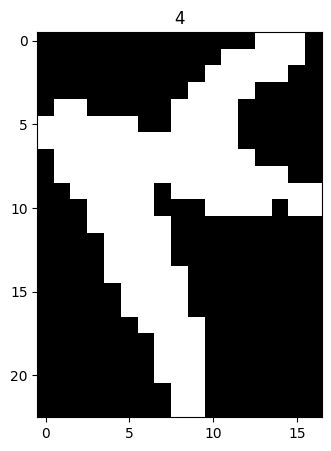

In [6]:
i = int(input('Enter the number of image sample: '))
plt.figure(figsize= (5, 5))
plt.imshow(digits['Data'][i], cmap= 'gray')
plt.title(digits['labels'][i]);

## 6.Image Preprocessing

The original images have different dimensions, so all images are resized to **8 × 8** pixels and normalized to the range `[0, 1]`.

After preprocessing:

```python
(60000, 8, 8)
```

All **60,000 images** now have a consistent shape suitable for model training.


In [7]:
print(f'Sample 1: {digits['Data'][30].shape}\nSample 2: {digits['Data'][100].shape}\nSmaple 3: {digits['Data'][450].shape}')

Sample 1: (18, 17)
Sample 2: (54, 11)
Smaple 3: (20, 32)


In [8]:
digits['Data'] = np.array([cv2.resize(img, (9, 9)) / 255 for img in digits['Data']])
print(f'{digits['Data'].shape}')

(60000, 9, 9)


## 7.Train-Test Split

The dataset is split into **80% training** and **20% testing** data using `train_test_split`.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(digits['Data'], digits['labels'], test_size= 0.2, random_state= 42)
print(f'X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}')

X_train shape: (48000, 9, 9)
X_test shape: (12000, 9, 9)
y_train shape: (48000,)
y_test shape: (12000,)


## 8.Neural Network Model

A fully connected neural network is created with ReLU activations, Dropout layers to reduce overfitting, and 10 output neurons for the 10 classes.

The model uses Adam optimizer and SparseCategoricalCrossentropy with from_logits=True.

In [10]:
model = Sequential([
    Flatten(),
    Dense(64, activation= 'relu'),
    Dense(128, activation= 'relu'),
    Dropout(0.2),
    Dense(256, activation= 'relu'),
    Dropout(0.35),
    Dense(10)
])
model.compile(loss= SparseCategoricalCrossentropy(from_logits= True),
             optimizer= 'adam',
             metrics= ['accuracy'])

## 9.Model Training

The model is trained for **30 epochs** with a batch size of **32**.
**20%** of the training data is used for validation.


In [11]:
his = model.fit(X_train, y_train,
                batch_size= 32,
                epochs= 30,
                verbose= 2,
                validation_split= 0.2)

Epoch 1/30
1200/1200 - 8s - 7ms/step - accuracy: 0.9205 - loss: 0.2591 - val_accuracy: 0.9695 - val_loss: 0.0955
Epoch 2/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9688 - loss: 0.1014 - val_accuracy: 0.9739 - val_loss: 0.0824
Epoch 3/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9750 - loss: 0.0820 - val_accuracy: 0.9767 - val_loss: 0.0655
Epoch 4/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9798 - loss: 0.0665 - val_accuracy: 0.9790 - val_loss: 0.0642
Epoch 5/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9808 - loss: 0.0579 - val_accuracy: 0.9806 - val_loss: 0.0666
Epoch 6/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9822 - loss: 0.0533 - val_accuracy: 0.9817 - val_loss: 0.0602
Epoch 7/30
1200/1200 - 3s - 3ms/step - accuracy: 0.9853 - loss: 0.0475 - val_accuracy: 0.9842 - val_loss: 0.0516
Epoch 8/30
1200/1200 - 5s - 4ms/step - accuracy: 0.9849 - loss: 0.0460 - val_accuracy: 0.9856 - val_loss: 0.0489
Epoch 9/30
1200/1200 - 3s - 3ms/step - accuracy: 0.9867 - loss: 0.0393 - val_accuracy: 0.9847 - 